# THMFP / HAAFP predictors — results

Inputs: `results/experiments.csv`, `results/predictions.csv` (out-of-fold predictions), `results/final_models.csv`,
`results/importance.csv`, `results/pdp.csv`. Produced by `uv run python -m src.train --all` and
`uv run python -m src.interpret`. Design: `src/features.py` (tiers), `src/cv.py` (schemes), `src/models.py`.

| Tier | Features |
|---|---|
| 1 chemistry | core-10 water-quality variables (log10 where skewed) |
| 2 context | + site group, treatment stage, WTP, main-stem position, month sin/cos, fold-fit site target-encoding |
| 3 network | + previous-month same-site target & TOC/HS, site history mean, upstream same-month target & TOC |

| Scheme | Holds out |
|---|---|
| random | random rows (optimistic reference) |
| month | 2 whole months per fold — new dates, known sites |
| site | 4 whole sites per fold — new sites, known dates |
| forward | last 4 months (May–Aug 2018) after training on the first 12 |

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore", category=FutureWarning)
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from preprocessing import style
from preprocessing.load import SITE_ORDER, GROUP_ORDER, GROUP_LABEL, TARGETS
from src.cv import SCHEMES
from src.experiments import EXPERIMENT_ORDER, NEW_FEATURE_BLOCK
style.apply()
GC = style.GROUP_COLORS
MODEL_COLORS = {"ridge": "#2a78d6", "hgb": "#eb6834", "xgb": "#1baf7a"}
TIER_COLORS = {"1": "#2a78d6", "2": "#eb6834", "3": "#1baf7a"}
TIER_LABEL = {"1": "T1 chemistry", "2": "T2 +context", "3": "T3 +network"}
BASE_STYLE = {"median": ":", "site_median": "--", "persistence": "-."}
R = Path.cwd().parent / "results"
exp = pd.read_csv(R / "experiments.csv"); exp["tier"] = exp["tier"].astype(str)
pred = pd.read_csv(R / "predictions.csv", dtype={"tier": str})
pred["Date"] = pd.to_datetime(pred["Date"], format="mixed")
import matplotlib.dates as mdates
MONTH_FMT = mdates.DateFormatter("%Y-%m")
final = pd.read_csv(R / "final_models.csv"); imp = pd.read_csv(R / "importance.csv"); pdp = pd.read_csv(R / "pdp.csv")
learned = exp[exp.tier.isin(["1", "2", "3"])]; base = exp[exp.tier == "base"]
pd.set_option("display.width", 180, "display.precision", 3)
print(exp.shape, pred.shape)

(162, 25) (135516, 12)


## 1. Results table — pooled out-of-fold R² (log10 target)

In [2]:
tab = learned.pivot_table(index=["target", "tier", "model"], columns="scheme", values="r2_log")[list(SCHEMES)]
tab_base = base.pivot_table(index=["target", "tier", "model"], columns="scheme", values="r2_log")[list(SCHEMES)]
pd.concat([tab_base, tab]).round(3)

scheme                   random  month   site  forward
target tier model                                     
HAAFP  base median       -0.004 -0.015 -0.017   -0.028
            persistence   0.325  0.330  0.299    0.055
            site_median   0.520  0.518 -0.017    0.409
THMFP  base median       -0.012 -0.098 -0.014   -1.069
            persistence   0.332  0.333  0.326    0.205
            site_median   0.203  0.182 -0.014   -0.852
HAAFP  1    hgb           0.708  0.516  0.710    0.433
            ridge         0.627  0.567  0.623    0.368
            xgb           0.721  0.555  0.715    0.458
       2    hgb           0.750  0.548  0.539    0.453
            ridge         0.679  0.583  0.518    0.477
            xgb           0.747  0.538  0.613    0.439
       3    hgb           0.760  0.609  0.576    0.510
            ridge         0.712  0.649  0.480    0.529
            xgb           0.771  0.614  0.677    0.524
THMFP  1    hgb           0.594  0.412  0.572   -0.215
            ridge         0.548  0.481  0.550   -0.033
            xgb           0.598  0.395  0.575   -0.202
       2    hgb           0.620  0.362  0.581   -0.322
            ridge         0.556  0.485  0.551   -0.020
            xgb           0.620  0.326  0.584   -0.370
       3    hgb           0.714  0.515  0.714   -0.095
            ridge         0.648  0.580  0.643    0.221
            xgb           0.715  0.531  0.700   -0.165

In [3]:
# best learned model per (target, tier, scheme) and the per-fold spread
best = (learned.sort_values("r2_log", ascending=False).drop_duplicates(["target", "tier", "scheme"])
               .sort_values(["target", "scheme", "tier"]))
best[["target", "scheme", "tier", "model", "r2_log", "r2_fold_mean", "r2_fold_sd", "rmse_log", "medape"]].round(3)

,target,scheme,tier,model,r2_log,r2_fold_mean,r2_fold_sd,rmse_log,medape
89,HAAFP,forward,1,xgb,0.458,0.458,0.000,0.261,0.296
90,HAAFP,forward,2,ridge,0.477,0.477,0.000,0.256,0.249
93,HAAFP,forward,3,ridge,0.529,0.529,0.000,0.243,0.259
69,HAAFP,month,1,ridge,0.567,0.569,0.318,0.191,0.210
72,HAAFP,month,2,ridge,0.583,0.582,0.223,0.188,0.224
75,HAAFP,month,3,ridge,0.649,0.646,0.183,0.172,0.198
62,HAAFP,random,1,xgb,0.721,0.719,0.066,0.153,0.189
64,HAAFP,random,2,hgb,0.750,0.748,0.044,0.145,0.173
68,HAAFP,random,3,xgb,0.771,0.770,0.037,0.139,0.165
80,HAAFP,site,1,xgb,0.715,0.662,0.109,0.155,0.198


## 2. R² by tier and model under each validation scheme

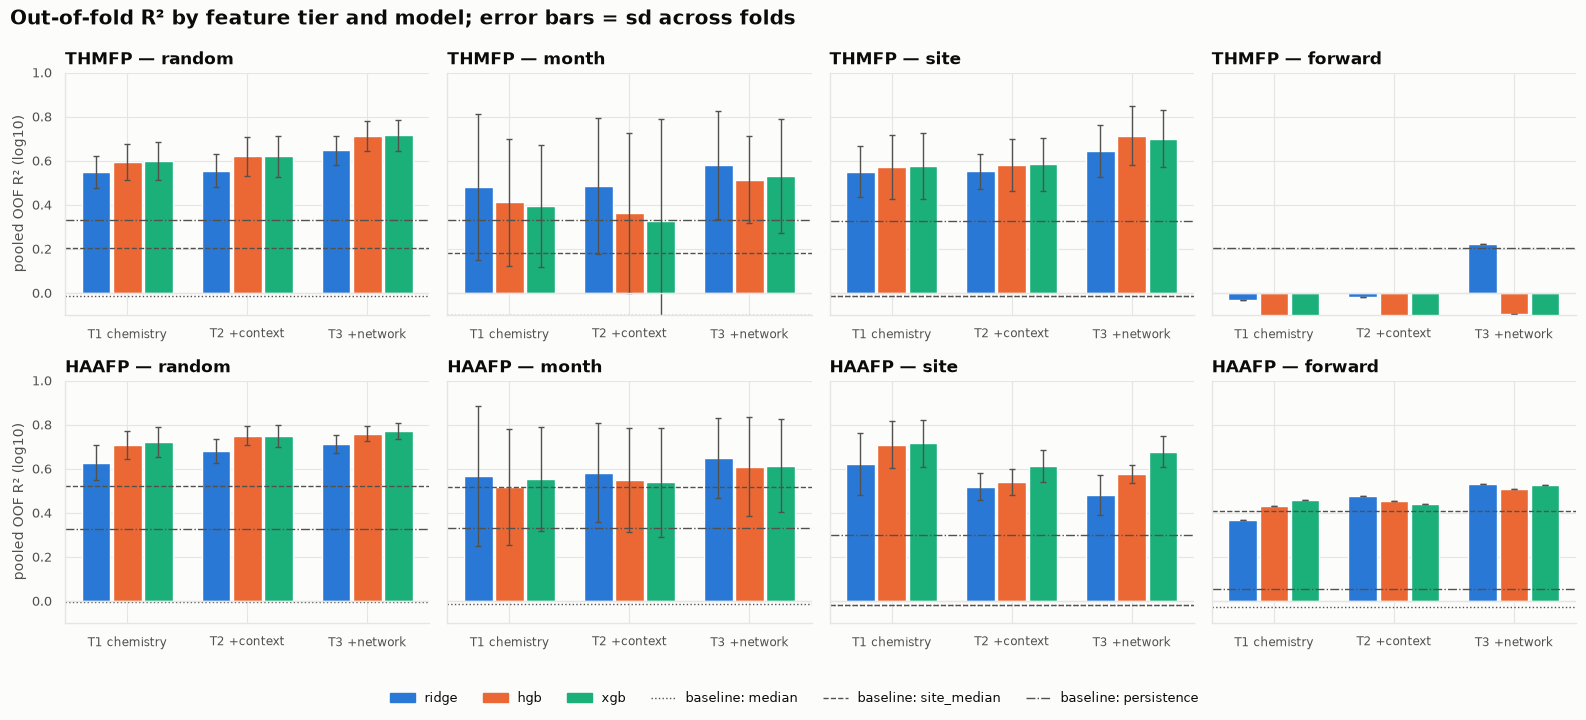

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=True)
w = 0.26
for i, t in enumerate(TARGETS):
    for j, s in enumerate(SCHEMES):
        ax = axes[i, j]; e = learned[(learned.target == t) & (learned.scheme == s)]
        for k, m in enumerate(MODEL_COLORS):
            d = e[e.model == m].set_index("tier").reindex(["1", "2", "3"])
            x = np.arange(3) + (k - 1) * w
            ax.bar(x, d.r2_log, width=w * 0.92, color=MODEL_COLORS[m], label=m)
            ax.errorbar(x, d.r2_log, yerr=d.r2_fold_sd, fmt="none", ecolor=style.TEXT_2, elinewidth=1, capsize=2)
        for b, ls in BASE_STYLE.items():
            v = base[(base.target == t) & (base.scheme == s) & (base.model == b)].r2_log
            if len(v): ax.axhline(v.iloc[0], color=style.TEXT_2, lw=1, ls=ls)
        ax.set_xticks(range(3)); ax.set_xticklabels([TIER_LABEL[k] for k in ["1", "2", "3"]], fontsize=8.5)
        ax.set_title(f"{t} — {s}"); ax.set_ylim(-0.1, 1.0); ax.axhline(0, color=style.GRID, lw=1)
        if j == 0: ax.set_ylabel("pooled OOF R² (log10)")
handles = [Patch(color=c, label=m) for m, c in MODEL_COLORS.items()] + \
          [Line2D([], [], color=style.TEXT_2, lw=1, ls=ls, label=f"baseline: {b}") for b, ls in BASE_STYLE.items()]
fig.legend(handles=handles, loc="lower center", ncol=6, bbox_to_anchor=(0.5, -0.03))
fig.suptitle("Out-of-fold R² by feature tier and model; error bars = sd across folds", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(rect=(0, 0.04, 1, 1)); style.savefig(fig, "20_cv_r2_by_tier_model"); plt.show()

## 3. What each tier adds (best model per tier)

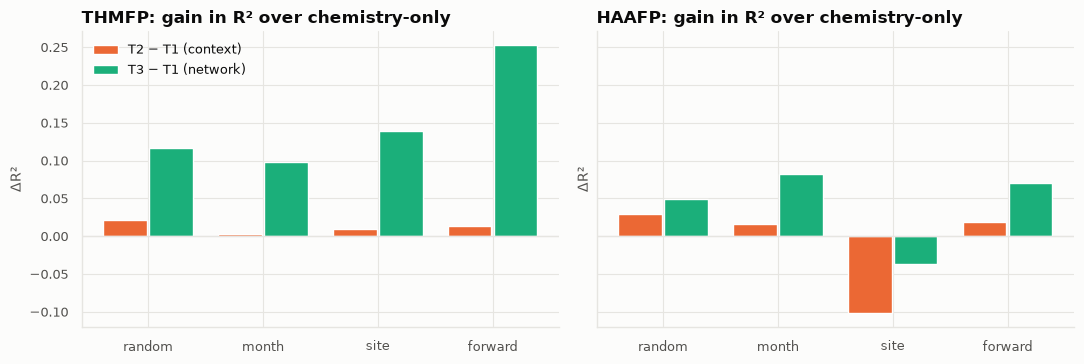

tier                1      2      3  T2−T1  T3−T1  T3−T2
target scheme                                           
HAAFP  forward  0.458  0.477  0.529  0.019  0.070  0.051
       month    0.567  0.583  0.649  0.016  0.083  0.067
       random   0.721  0.750  0.771  0.029  0.050  0.020
       site     0.715  0.613  0.677 -0.102 -0.037  0.065
THMFP  forward -0.033 -0.020  0.221  0.013  0.253  0.240
       month    0.481  0.485  0.580  0.003  0.098  0.095
       random   0.598  0.620  0.715  0.022  0.117  0.095
       site     0.575  0.584  0.714  0.009  0.139  0.130

In [5]:
gain = best.pivot_table(index=["target", "scheme"], columns="tier", values="r2_log")
gain["T2−T1"] = gain["2"] - gain["1"]; gain["T3−T1"] = gain["3"] - gain["1"]; gain["T3−T2"] = gain["3"] - gain["2"]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, t in zip(axes, TARGETS):
    g = gain.loc[t].reindex(list(SCHEMES))
    x = np.arange(len(SCHEMES))
    ax.bar(x - 0.2, g["T2−T1"], width=0.38, color=TIER_COLORS["2"], label="T2 − T1 (context)")
    ax.bar(x + 0.2, g["T3−T1"], width=0.38, color=TIER_COLORS["3"], label="T3 − T1 (network)")
    ax.axhline(0, color=style.GRID, lw=1); ax.set_xticks(x); ax.set_xticklabels(SCHEMES)
    ax.set_title(f"{t}: gain in R² over chemistry-only"); ax.set_ylabel("ΔR²")
axes[0].legend()
fig.tight_layout(); style.savefig(fig, "21_tier_gain"); plt.show()
gain.round(3)

## 4. Predicted vs observed on held-out sites (best model per tier)

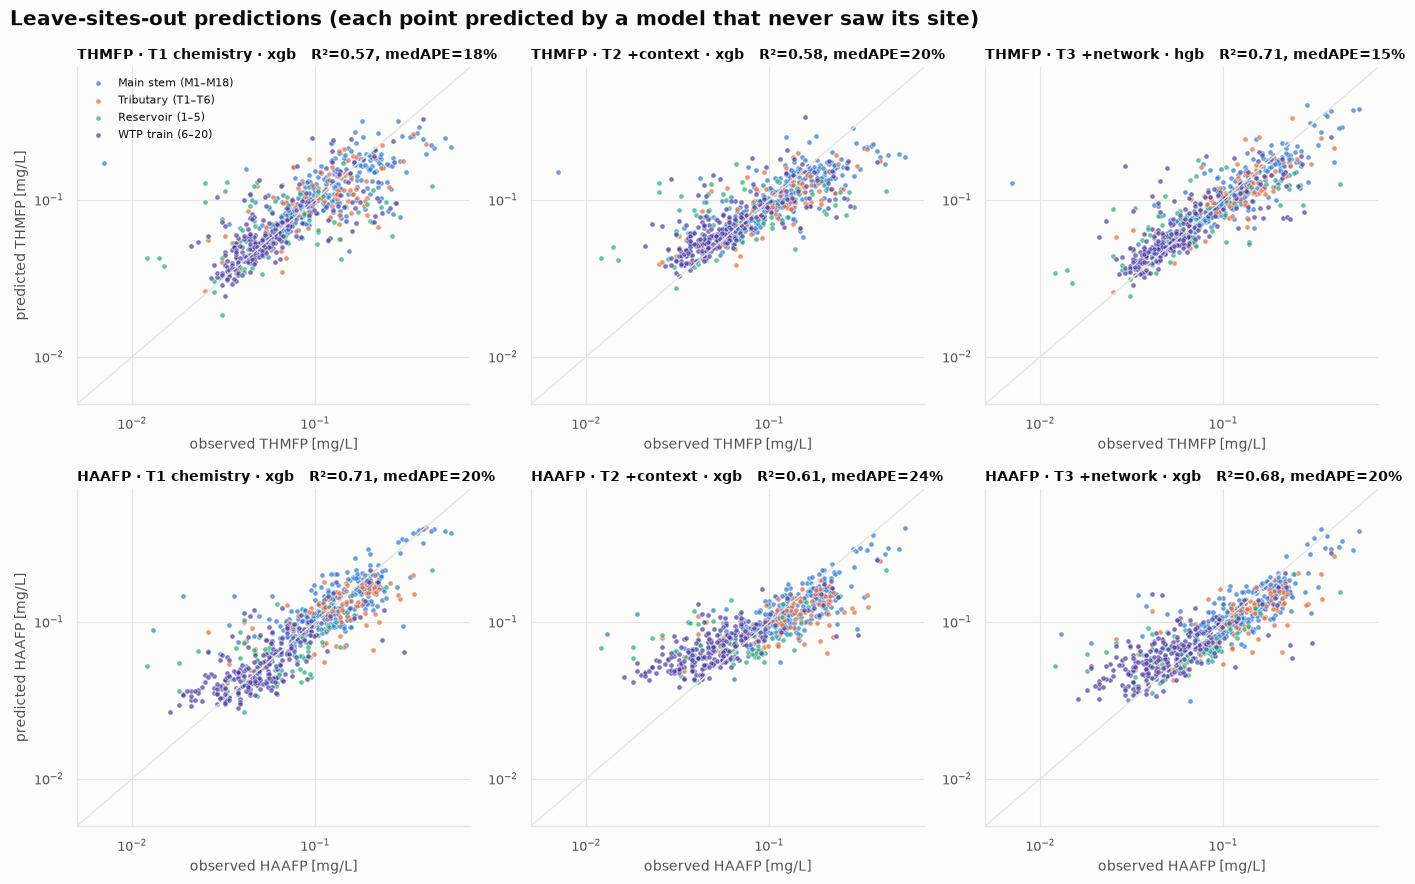

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for i, t in enumerate(TARGETS):
    for j, tier in enumerate(["1", "2", "3"]):
        ax = axes[i, j]
        b = best[(best.target == t) & (best.scheme == "site") & (best.tier == tier)].iloc[0]
        p = pred[(pred.target == t) & (pred.scheme == "site") & (pred.tier == tier) & (pred.model == b.model)]
        for g in GROUP_ORDER:
            s = p[p.group == g]
            ax.scatter(10 ** s.y, 10 ** s.y_pred, s=14, color=GC[g], alpha=0.7, edgecolors=style.SURFACE, linewidths=0.5, label=GROUP_LABEL[g])
        lim = [0.005, 0.7]; ax.plot(lim, lim, color=style.GRID, lw=1); ax.set_xlim(lim); ax.set_ylim(lim)
        ax.set_xscale("log"); ax.set_yscale("log")
        ax.set_title(f"{t} · {TIER_LABEL[tier]} · {b.model}   R²={b.r2_log:.2f}, medAPE={b.medape:.0%}", fontsize=10)
        ax.set_xlabel(f"observed {t} [mg/L]"); ax.set_ylabel(f"predicted {t} [mg/L]" if j == 0 else "")
axes[0, 0].legend(fontsize=8, loc="upper left")
fig.suptitle("Leave-sites-out predictions (each point predicted by a model that never saw its site)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); style.savefig(fig, "22_pred_vs_obs_site"); plt.show()

## 5. Performance by site group

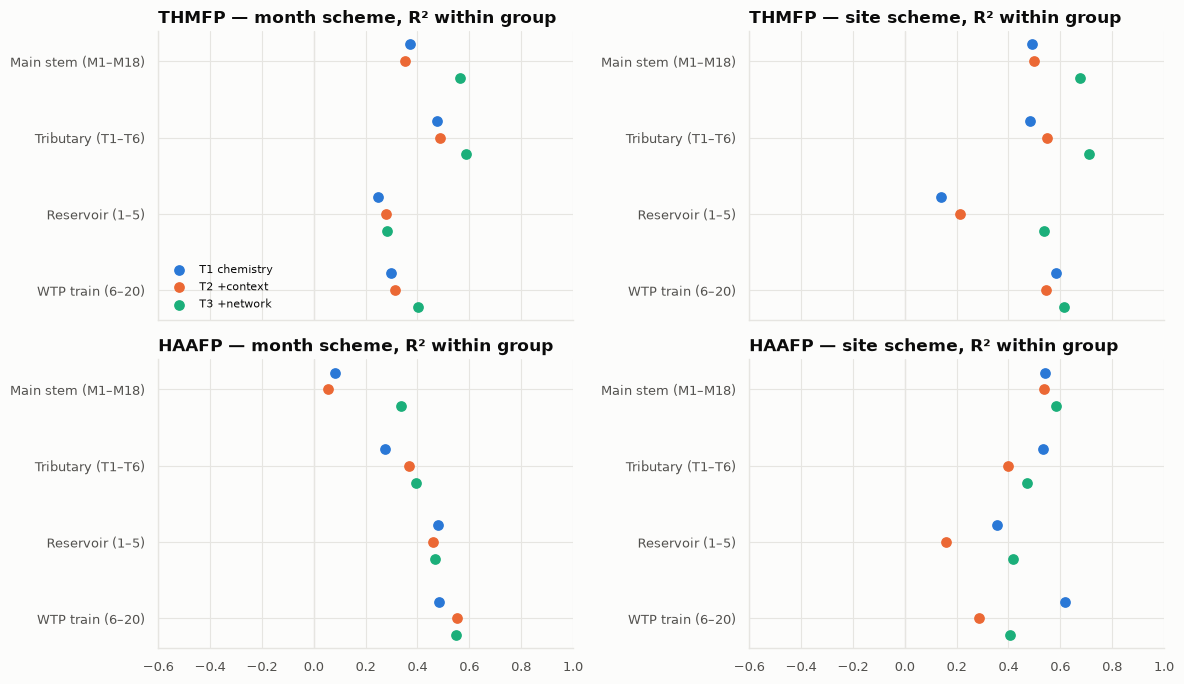

tier                        1     2     3
target scheme group                      
HAAFP  month  main_stem  0.08  0.05  0.34
              reservoir  0.48  0.46  0.47
              treatment  0.48  0.55  0.55
              tributary  0.28  0.37  0.39
       site   main_stem  0.54  0.54  0.58
              reservoir  0.35  0.16  0.42
              treatment  0.62  0.29  0.41
              tributary  0.53  0.40  0.47
THMFP  month  main_stem  0.37  0.35  0.56
              reservoir  0.25  0.28  0.28
              treatment  0.30  0.31  0.40
              tributary  0.48  0.49  0.59
       site   main_stem  0.49  0.50  0.68
              reservoir  0.14  0.21  0.54
              treatment  0.58  0.55  0.61
              tributary  0.48  0.55  0.71

In [7]:
rows = []
for _, b in best[best.scheme.isin(["month", "site"])].iterrows():
    for g in GROUP_ORDER:
        rows.append({"target": b.target, "scheme": b.scheme, "tier": b.tier, "group": g, "r2": b[f"r2_{g}"], "rmse": b[f"rmse_{g}"]})
pg = pd.DataFrame(rows)
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for i, t in enumerate(TARGETS):
    for j, s in enumerate(["month", "site"]):
        ax = axes[i, j]; d = pg[(pg.target == t) & (pg.scheme == s)]
        for k, tier in enumerate(["1", "2", "3"]):
            dd = d[d.tier == tier].set_index("group").reindex(GROUP_ORDER)
            ax.scatter(dd.r2, np.arange(4) + (k - 1) * 0.22, color=TIER_COLORS[tier], s=45, label=TIER_LABEL[tier], zorder=3)
        ax.set_yticks(range(4)); ax.set_yticklabels([GROUP_LABEL[g] for g in GROUP_ORDER]); ax.invert_yaxis()
        ax.axvline(0, color=style.GRID, lw=1); ax.set_xlim(-0.6, 1); ax.set_title(f"{t} — {s} scheme, R² within group")
axes[0, 0].legend(loc="lower left", fontsize=8)
fig.tight_layout(); style.savefig(fig, "23_r2_by_group"); plt.show()
pg.pivot_table(index=["target", "scheme", "group"], columns="tier", values="r2").round(2)

## 6. Final models: permutation importance (held-out sites) and partial dependence

In [8]:
final

,target,tier,model,path,best_params,r2_month,r2_site,r2_forward
0,THMFP,t3_basin,ridge,models/THMFP_t3_basin_ridge.joblib,{},0.681,0.682,0.416
1,HAAFP,t4_all,ridge,models/HAAFP_t4_all_ridge.joblib,{},0.710,0.661,0.594


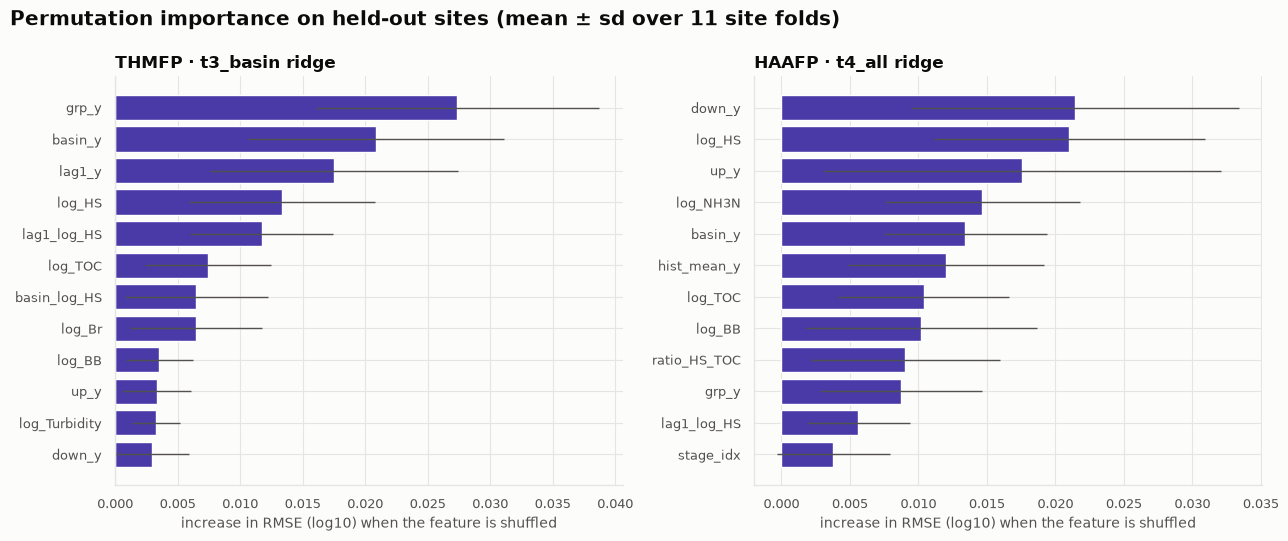

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, t in zip(axes, TARGETS):
    d = imp[imp.target == t].head(12).iloc[::-1]
    f = final[final.target == t].iloc[0]
    ax.barh(d.feature, d["mean"], xerr=d["sd"], color=TIER_COLORS.get(str(f.tier), "#4a3aa7"), error_kw={"ecolor": style.TEXT_2, "elinewidth": 1})
    ax.set_title(f"{t} · {f.tier} {f.model}")
    ax.set_xlabel("increase in RMSE (log10) when the feature is shuffled")
fig.suptitle("Permutation importance on held-out sites (mean ± sd over 11 site folds)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); style.savefig(fig, "24_permutation_importance"); plt.show()

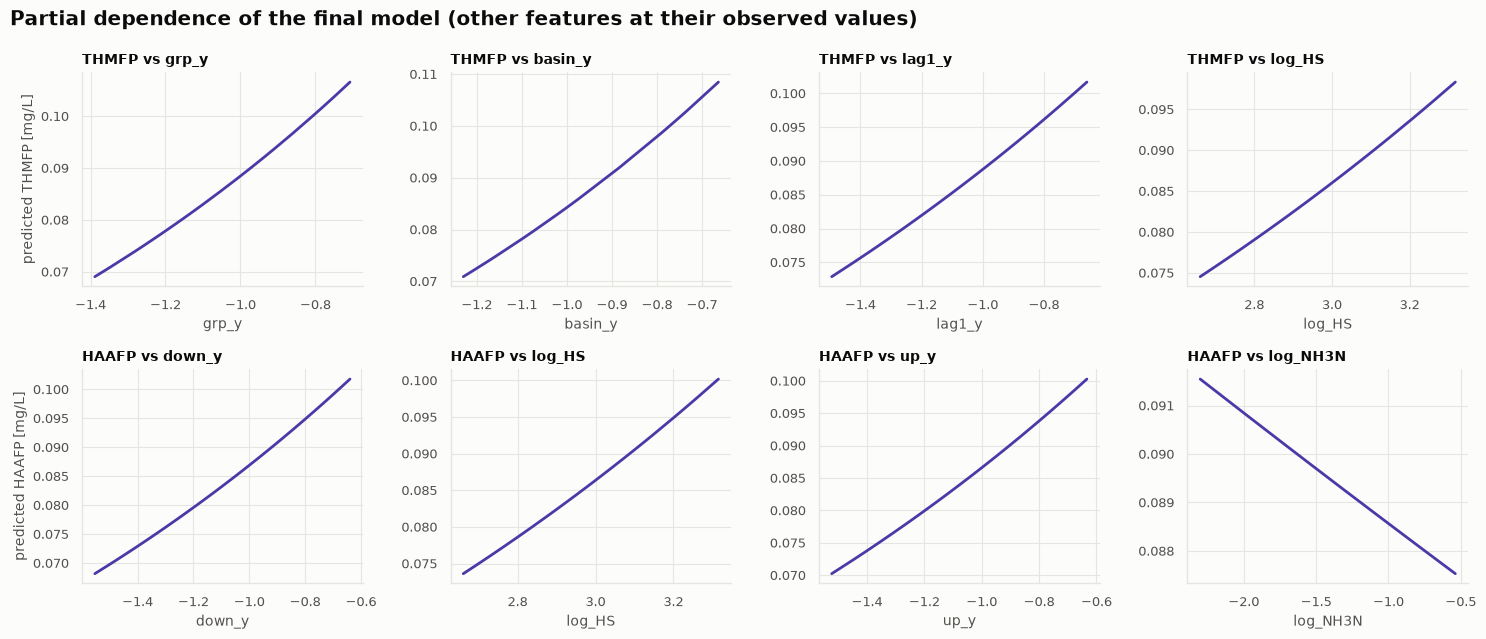

In [10]:
feats = {t: pdp[pdp.target == t].feature.unique()[:4] for t in TARGETS}
fig, axes = plt.subplots(2, 4, figsize=(15, 6.5))
for i, t in enumerate(TARGETS):
    for j, f in enumerate(feats[t]):
        ax = axes[i, j]; d = pdp[(pdp.target == t) & (pdp.feature == f)]
        ax.plot(d.x, 10 ** d.y_pred, color=TIER_COLORS.get(str(final[final.target == t].iloc[0].tier), "#4a3aa7"))
        ax.set_title(f"{t} vs {f}", fontsize=10); ax.set_xlabel(f); ax.set_ylabel(f"predicted {t} [mg/L]" if j == 0 else "")
    for j in range(len(feats[t]), 4): axes[i, j].axis("off")
fig.suptitle("Partial dependence of the final model (other features at their observed values)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); style.savefig(fig, "25_partial_dependence"); plt.show()

## 7. Where the models fail: residuals by site and by month (leave-months-out, best T3 model)

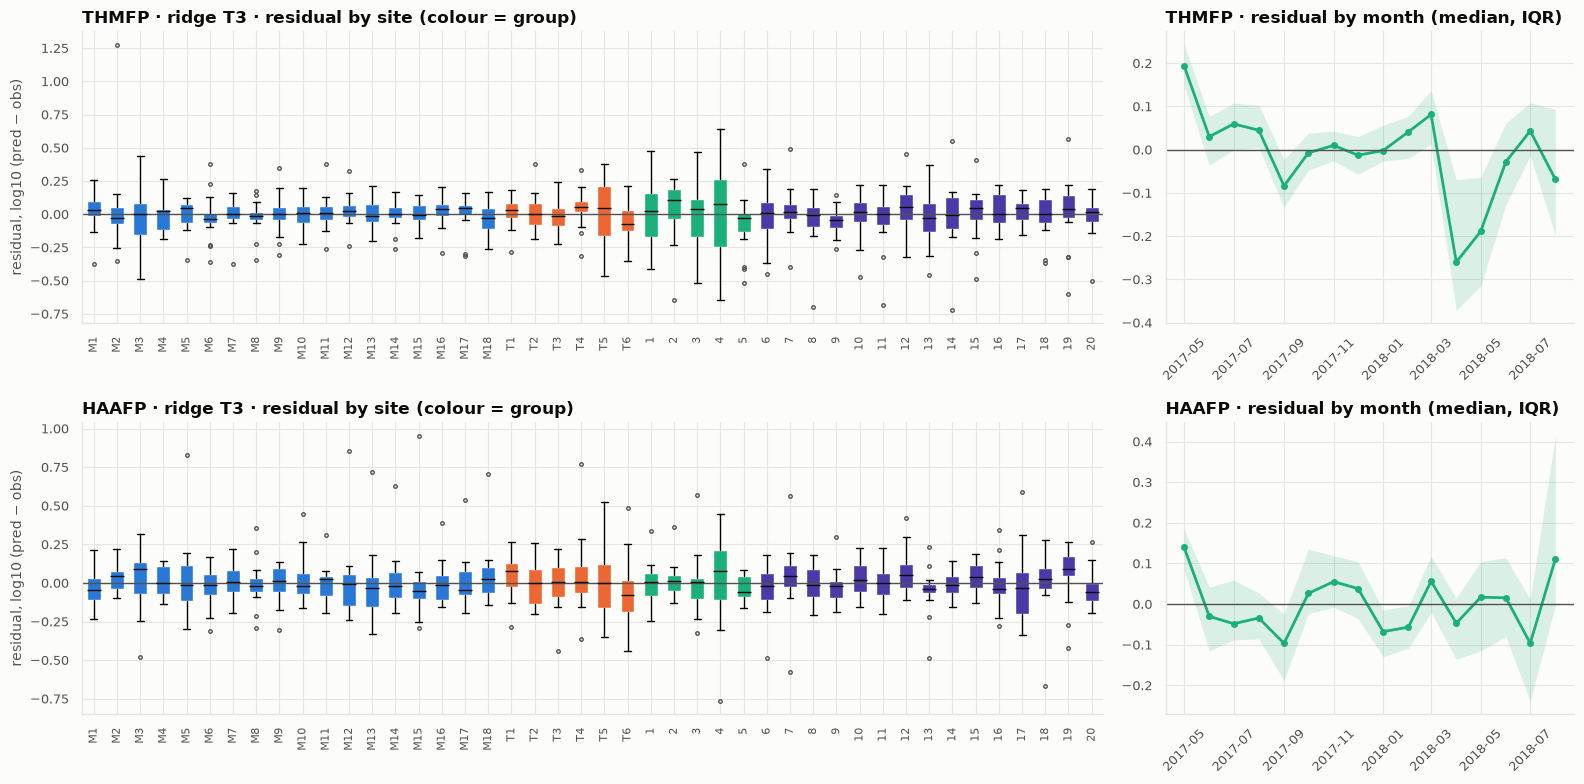

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8), gridspec_kw={"width_ratios": [3, 1.2]})
for i, t in enumerate(TARGETS):
    b = best[(best.target == t) & (best.scheme == "month") & (best.tier == "3")].iloc[0]
    p = pred[(pred.target == t) & (pred.scheme == "month") & (pred.tier == "3") & (pred.model == b.model)].copy()
    p["resid"] = p.y_pred - p.y
    order = [s for s in SITE_ORDER if s in set(p.Site)]
    ax = axes[i, 0]
    data = [p.loc[p.Site == s, "resid"].to_numpy() for s in order]
    bp = ax.boxplot(data, positions=range(len(order)), widths=0.6, patch_artist=True, showfliers=True,
                    flierprops={"markersize": 2.5, "markeredgecolor": style.TEXT_2}, medianprops={"color": style.TEXT})
    for patch, s in zip(bp["boxes"], order):
        patch.set_facecolor(GC[p.loc[p.Site == s, "group"].iloc[0]]); patch.set_edgecolor(style.SURFACE)
    ax.axhline(0, color=style.TEXT_2, lw=1); ax.set_xticks(range(len(order))); ax.set_xticklabels(order, rotation=90, fontsize=8)
    ax.set_ylabel("residual, log10 (pred − obs)"); ax.set_title(f"{t} · {b.model} T3 · residual by site (colour = group)")
    ax = axes[i, 1]
    m = p.groupby("Date").resid.agg(["median", lambda s: s.quantile(0.25), lambda s: s.quantile(0.75)])
    m.columns = ["med", "q1", "q3"]
    ax.fill_between(m.index, m.q1, m.q3, color=TIER_COLORS["3"], alpha=0.15, linewidth=0)
    ax.plot(m.index, m.med, color=TIER_COLORS["3"], marker="o", markersize=4)
    ax.axhline(0, color=style.TEXT_2, lw=1); ax.set_title(f"{t} · residual by month (median, IQR)")
    ax.xaxis.set_major_formatter(MONTH_FMT); ax.tick_params(axis="x", rotation=45)
fig.tight_layout(); style.savefig(fig, "26_residuals_site_month"); plt.show()

## 8. Out-of-fold time series at four sites (leave-months-out): chemistry-only vs network tier

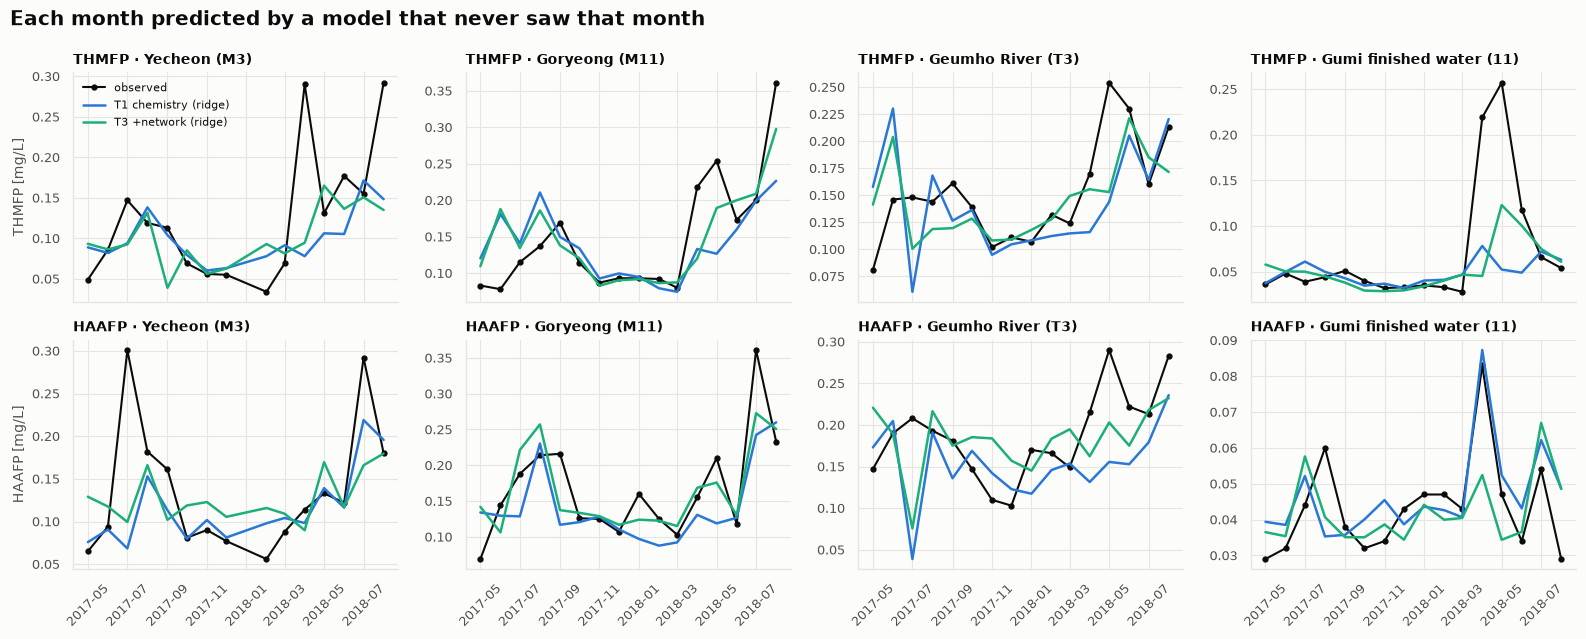

In [12]:
show_sites = ["M3", "M11", "T3", "11"]
fig, axes = plt.subplots(2, 4, figsize=(16, 6.5), sharex=True)
for i, t in enumerate(TARGETS):
    for j, s in enumerate(show_sites):
        ax = axes[i, j]
        obs = pred[(pred.target == t) & (pred.scheme == "month") & (pred.tier == "1") & (pred.Site == s)].drop_duplicates("Date").sort_values("Date")
        ax.plot(obs.Date, 10 ** obs.y, color=style.TEXT, lw=1.5, marker="o", markersize=3.5, label="observed")
        for tier in ["1", "3"]:
            b = best[(best.target == t) & (best.scheme == "month") & (best.tier == tier)].iloc[0]
            p = pred[(pred.target == t) & (pred.scheme == "month") & (pred.tier == tier) & (pred.model == b.model) & (pred.Site == s)].sort_values("Date")
            ax.plot(p.Date, 10 ** p.y_pred, color=TIER_COLORS[tier], lw=1.8, label=f"{TIER_LABEL[tier]} ({b.model})")
        name = {"M3": "Yecheon (M3)", "M11": "Goryeong (M11)", "T3": "Geumho River (T3)", "11": "Gumi finished water (11)"}[s]
        ax.set_title(f"{t} · {name}", fontsize=10)
        ax.xaxis.set_major_formatter(MONTH_FMT); ax.tick_params(axis="x", rotation=45)
        if j == 0: ax.set_ylabel(f"{t} [mg/L]")
axes[0, 0].legend(fontsize=8)
fig.suptitle("Each month predicted by a model that never saw that month", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); style.savefig(fig, "27_oof_timeseries"); plt.show()

## 9. Findings (round 0)

See `reports/modeling_findings.md` for the written summary (recommended model per target, what the spatial /
temporal context adds, per-group behaviour, safeguards against leakage, limitations and next steps).

## 10. Improvement round 1 — feature ablations

Pre-registered feature sets on top of tier 3 (`src/experiments.py`), same models, same nested search, same
folds; `site` and `random` schemes repeated over 3 seeds. `t3` is the baseline re-run under this protocol.

| Experiment | Adds |
|---|---|
| `t3_chem` | LC-OCD fractions as ratios to TOC, Temp × log TOC, sparse extras (COD, SS, DO, BOD, NH3-N, SUVA, Aromaticity, MolWeight) |
| `t3_xlag` | other target's lag-1 / history / upstream value, own lag-2, upstream site's lag-1 |
| `t3_basin` | leave-one-out same-month means over the other river sites (target, TOC, HS) and own group, downstream neighbour, plant raw-water target |
| `t4_all` | union |

In [13]:
abl = exp[exp.tier.isin(EXPERIMENT_ORDER)].copy()
abl_tab = abl.pivot_table(index=["target", "model", "tier"], columns="scheme", values="r2_log")
abl_tab = abl_tab.reindex(columns=[s for s in ["month", "site", "forward", "random"] if s in abl_tab.columns])
abl_tab["honest_mean"] = abl_tab[["month", "site"]].mean(axis=1)
abl_tab = abl_tab.reset_index()
abl_tab["tier"] = pd.Categorical(abl_tab["tier"], EXPERIMENT_ORDER, ordered=True)
abl_tab = abl_tab.sort_values(["target", "model", "tier"]).set_index(["target", "model", "tier"])
abl_tab.round(3)

scheme                 month   site  forward  honest_mean
target model tier                                        
HAAFP  hgb   t4_all    0.648  0.613    0.534        0.630
       ridge t3        0.650  0.539    0.514        0.595
             t3_chem   0.608  0.633    0.496        0.621
             t3_xlag   0.651  0.589    0.507        0.620
             t3_basin  0.723  0.616    0.624        0.670
             t4_all    0.710  0.661    0.594        0.686
       xgb   t3        0.614  0.652    0.524        0.633
             t3_chem   0.625  0.685    0.526        0.655
             t3_xlag   0.618  0.632    0.502        0.625
             t3_basin  0.629  0.672    0.547        0.651
             t4_all    0.658  0.681    0.555        0.670
THMFP  hgb   t3_basin  0.650  0.705    0.265        0.677
       ridge t3        0.618  0.678    0.323        0.648
             t3_chem   0.632  0.673    0.228        0.653
             t3_xlag   0.587  0.680    0.374        0.634
             t3_basin  0.681  0.682    0.416        0.682
             t4_all    0.661  0.653    0.427        0.657
       xgb   t3        0.531  0.702   -0.165        0.617
             t3_chem   0.553  0.723   -0.034        0.638
             t3_xlag   0.537  0.725    0.013        0.631
             t3_basin  0.598  0.723   -0.382        0.661
             t4_all    0.599  0.749   -0.159        0.674

In [14]:
# delta vs the t3 baseline, same target / model / scheme
base_t3 = abl[abl.tier == "t3"].set_index(["target", "model", "scheme"])["r2_log"]
abl["delta"] = abl.r2_log.to_numpy() - base_t3.reindex(pd.MultiIndex.from_frame(abl[["target", "model", "scheme"]])).to_numpy()
delta = abl.pivot_table(index=["target", "tier"], columns=["scheme", "model"], values="delta")
delta = delta.reindex(EXPERIMENT_ORDER, level="tier")
delta.round(3)

scheme          forward         month          site       
model             ridge    xgb  ridge    xgb  ridge    xgb
target tier                                               
HAAFP  t3         0.000  0.000  0.000  0.000  0.000  0.000
       t3_chem   -0.018  0.002 -0.042  0.010  0.094  0.033
       t3_xlag   -0.007 -0.022  0.002  0.004  0.050 -0.020
       t3_basin   0.110  0.023  0.074  0.015  0.077  0.020
       t4_all     0.080  0.030  0.060  0.044  0.122  0.029
THMFP  t3         0.000  0.000  0.000  0.000  0.000  0.000
       t3_chem   -0.096  0.131  0.015  0.022 -0.006  0.021
       t3_xlag    0.051  0.178 -0.030  0.006  0.002  0.023
       t3_basin   0.093 -0.216  0.064  0.067  0.004  0.021
       t4_all     0.104  0.006  0.043  0.068 -0.025  0.047

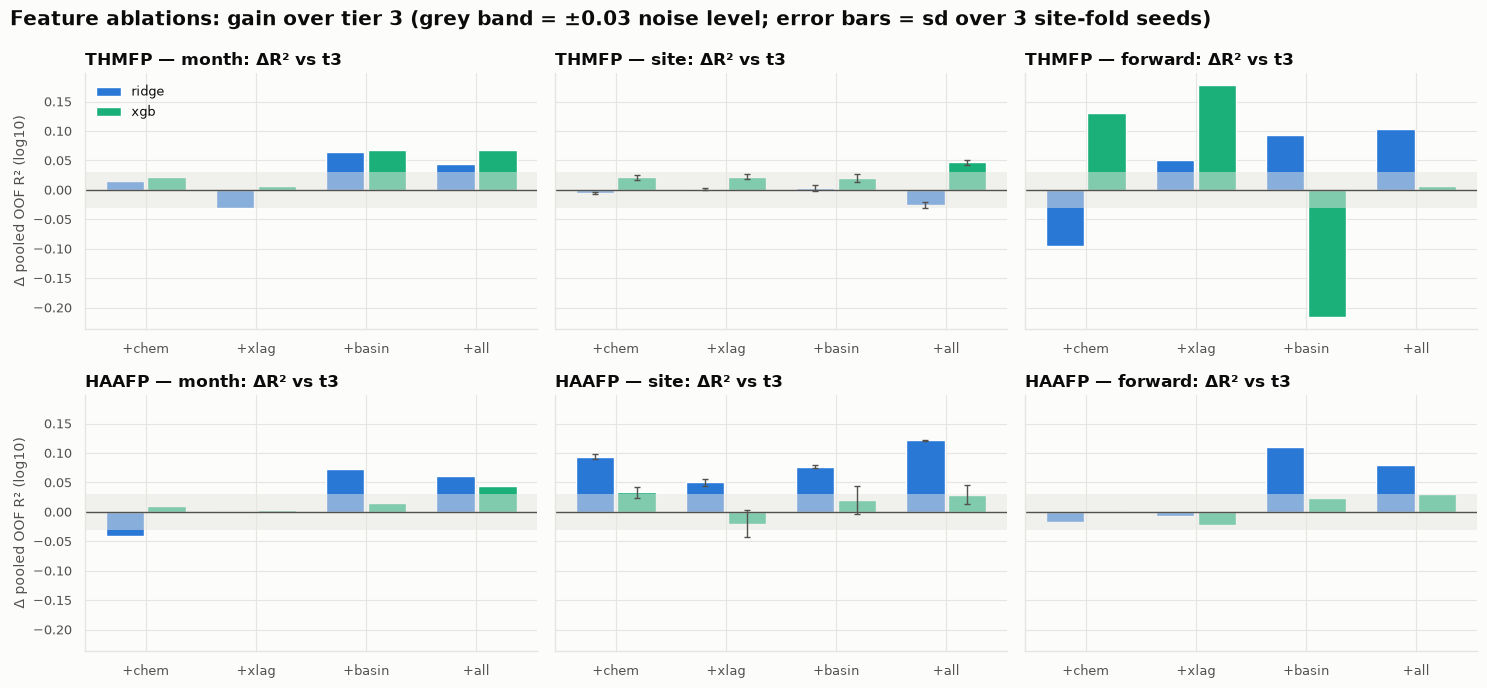

In [15]:
schemes_abl = ["month", "site", "forward"]
exps = [e for e in EXPERIMENT_ORDER if e != "t3"]
fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharey=True)
w = 0.38
for i, t in enumerate(TARGETS):
    for j, s in enumerate(schemes_abl):
        ax = axes[i, j]
        for k, m in enumerate(["ridge", "xgb"]):
            d = abl[(abl.target == t) & (abl.scheme == s) & (abl.model == m)].set_index("tier").reindex(exps)
            x = np.arange(len(exps)) + (k - 0.5) * w
            ax.bar(x, d.delta, width=w * 0.92, color=MODEL_COLORS[m], label=m)
            err = d.r2_seed_sd.fillna(0) if s == "site" else np.zeros(len(exps))
            if s == "site": ax.errorbar(x, d.delta, yerr=err, fmt="none", ecolor=style.TEXT_2, elinewidth=1, capsize=2)
        ax.axhline(0, color=style.TEXT_2, lw=1); ax.axhspan(-0.03, 0.03, color=style.GRID, alpha=0.5, lw=0)
        ax.set_xticks(range(len(exps))); ax.set_xticklabels([e.replace("t3_", "+").replace("t4_all", "+all") for e in exps])
        ax.set_title(f"{t} — {s}: ΔR² vs t3")
        if j == 0: ax.set_ylabel("Δ pooled OOF R² (log10)")
axes[0, 0].legend(loc="upper left")
fig.suptitle("Feature ablations: gain over tier 3 (grey band = ±0.03 noise level; error bars = sd over 3 site-fold seeds)",
             x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); style.savefig(fig, "28_ablation_delta_r2"); plt.show()

In [16]:
# month-wide offset diagnostic: share of residual variance explained by a per-Date mean residual (month scheme, xgb)
rows = []
for t in TARGETS:
    for e in EXPERIMENT_ORDER:
        for m in ["ridge", "xgb"]:
            p = pred[(pred.target == t) & (pred.scheme == "month") & (pred.tier == e) & (pred.model == m)].copy()
            if p.empty: continue
            p["res"] = p.y_pred - p.y
            off = p.groupby("Date").res.transform("mean")
            rows.append({"target": t, "experiment": e, "model": m, "resid_var": p.res.var(),
                         "month_offset_share": 1 - (p.res - off).var() / p.res.var()})
off_tab = pd.DataFrame(rows).pivot_table(index=["target", "experiment"], columns="model", values="month_offset_share").reindex(EXPERIMENT_ORDER, level="experiment")
(off_tab * 100).round(0).astype(int).astype(str) + " %"

model             ridge   xgb
target experiment            
HAAFP  t3          22 %  26 %
       t3_chem     26 %  26 %
       t3_xlag     23 %  25 %
       t3_basin     8 %  25 %
       t4_all       9 %  23 %
THMFP  t3          26 %  32 %
       t3_chem     26 %  31 %
       t3_xlag     30 %  29 %
       t3_basin    11 %  18 %
       t4_all      19 %  20 %

In [17]:
# final models after round 1 (results/final_models.csv) and their permutation importance with new features highlighted
final

,target,tier,model,path,best_params,r2_month,r2_site,r2_forward
0,THMFP,t3_basin,ridge,models/THMFP_t3_basin_ridge.joblib,{},0.681,0.682,0.416
1,HAAFP,t4_all,ridge,models/HAAFP_t4_all_ridge.joblib,{},0.710,0.661,0.594


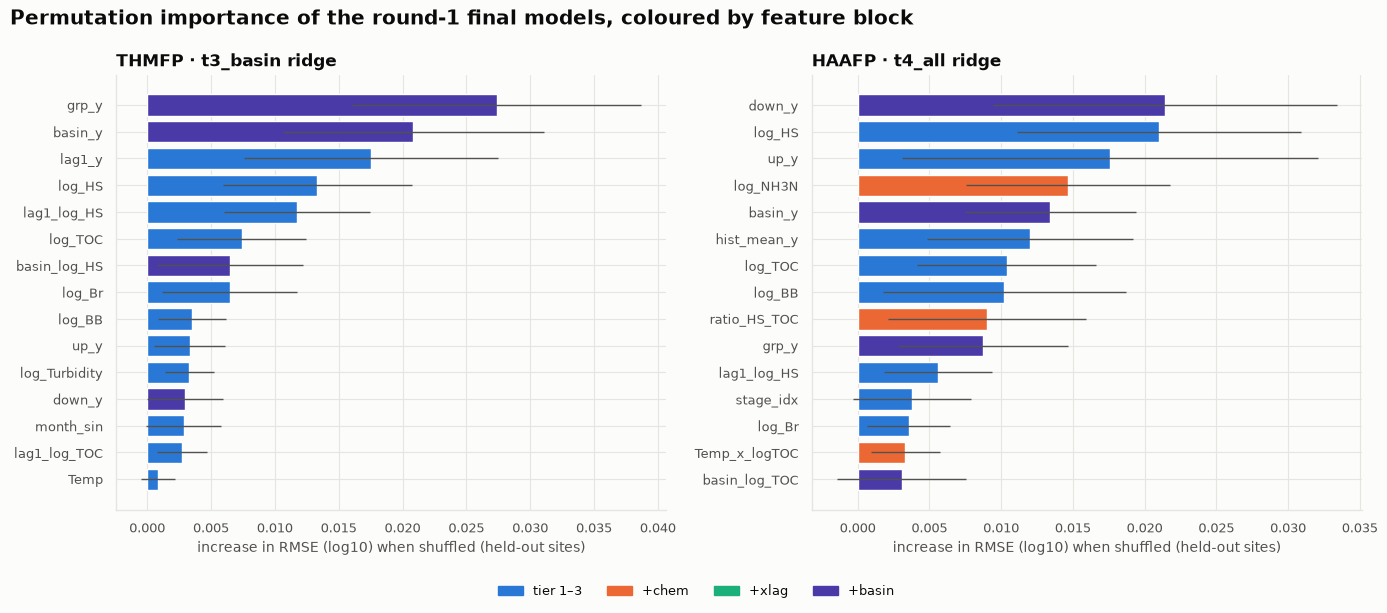

In [18]:
BLOCK_COLORS = {"base": "#2a78d6", "chem": "#eb6834", "xlag": "#1baf7a", "basin": "#4a3aa7"}
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, t in zip(axes, TARGETS):
    f = final[final.target == t].iloc[0]
    d = imp[imp.target == t].head(15).iloc[::-1]
    colors = [BLOCK_COLORS[NEW_FEATURE_BLOCK.get(x, "base")] for x in d.feature]
    ax.barh(d.feature, d["mean"], xerr=d["sd"], color=colors, error_kw={"ecolor": style.TEXT_2, "elinewidth": 1})
    ax.set_title(f"{t} · {f.tier} {f.model}"); ax.set_xlabel("increase in RMSE (log10) when shuffled (held-out sites)")
handles = [Patch(color=c, label={"base": "tier 1–3", "chem": "+chem", "xlag": "+xlag", "basin": "+basin"}[b]) for b, c in BLOCK_COLORS.items()]
fig.legend(handles=handles, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Permutation importance of the round-1 final models, coloured by feature block", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(rect=(0, 0.04, 1, 1)); style.savefig(fig, "29_new_feature_importance"); plt.show()

## 11. Findings (round 1)

See `reports/modeling_findings.md` §6.